# UFC FIGHT OUTCOME PREDICTION NOTEBOOK (2010-2026)
## Jordin Chavez
dataset source: Kaggle

In [1]:
import pandas as pd

1. Data Cleaning & Preprocessing


In [2]:
df_old = pd.read_csv('UFC.csv')

In [3]:
# Convert your date column to datetime if you haven't already
df_old['date'] = pd.to_datetime(df_old['date'])

# Filter for the 'Modern Era' (e.g., 2010 onwards)
df = df_old[df_old['date'].dt.year >= 2010].copy()

# Check how many rows are left
print(f"Original fights: {len(df_old)}")
print(f"Modern fights: {len(df)}")

Original fights: 8662
Modern fights: 7397


2. Give fighters initial stats for the beginning of their careers

In [4]:
def initial_empty_stats():
    return {
        #FIGHTER ELO
        'elo': 1000,
        'elo_rd': 350,
        'elo_sigma': 0.06,

        #Results
        'total_fights': 0,
        'total_wins': 0,
        'total_losses': 0,
        'total_time_seconds': 0,
        'knock_downs': 0,
        'title_fight_wins': 0,
        'avg_opponent_wins': 0,
        'days_since_last_fight': float('nan'),
        'last_fight_date': pd.NaT,
        'current_win_streak': 0,
        'current_lose_streak': 0,
        

        #Physical Stats
        'height_cms': float('nan'),
        'reach_cms': float('nan'),
        'age': float('nan'),
        'dob': float('nan'),

        # Offensive Striking
        'sig_strikes_landed': 0,
        'sig_strikes_attempted': 0,
        'ground_strikes_landed': 0,
        'ground_strikes_attempted': 0,
        'head_landed': 0,
        'head_attempted': 0,
        'body_landed': 0,
        'body_attempted': 0,
        'leg_landed': 0,
        'leg_attempted': 0,
        'clinch_landed': 0,
        'clinch_attempted': 0,

        # Defensive Striking
        'sig_strikes_absorbed': 0,
        'sig_strikes_defended': 0,

        # Grappling
        'takedowns_landed': 0,
        'takedowns_attempted': 0,
        'subs_attempted': 0,
        'control_time': 0,
        'takedowns_defended': 0,

        # Method of winning
        'ko_wins': 0,
        'sub_wins': 0,
        'dec_wins': 0,

        # Method of lossing
        'ko_losses': 0,
        'sub_losses': 0,
        'dec_losses': 0,

        #Draw/No Contest
        'draws': 0,
        'no_contests': 0,
 
    }

3. Elo system to give fighters a ranking

In [5]:
def elo_expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))


def _adaptive_elo_k(pre_stats, base_k=24):
    """Glicko-2-like learning rate: larger early, smaller as career stabilizes."""
    fights = pre_stats.get('total_fights', 0) or 0
    rd = pre_stats.get('elo_rd', 350) or 350
    streak = pre_stats.get('current_win_streak', 0) or 0

    # High uncertainty and low experience should move faster.
    uncertainty_factor = max(0.55, min(rd / 350, 1.6))
    experience_factor = 1.15 / (1 + fights / 9)

    # Reward hot streaks early in a career, then taper it down.
    streak_bonus = 1.0 + min(max(streak, 0), 5) * (0.10 if fights < 8 else 0.03)

    return base_k * uncertainty_factor * experience_factor * streak_bonus


def _next_elo_rd(pre_stats, rd_floor=60):
    fights = pre_stats.get('total_fights', 0) or 0
    current_rd = pre_stats.get('elo_rd', 350) or 350

    # Early careers settle faster after a few fights; veterans barely move.
    decay = 0.92 if fights < 6 else 0.97
    return max(rd_floor, current_rd * decay)


def update_elo_ratings(elo_ratings, elo_rds, red_fighter, blue_fighter, row, red_stats, blue_stats, base_k=24):
    red_rating = elo_ratings.get(red_fighter, 1000)
    blue_rating = elo_ratings.get(blue_fighter, 1000)
    red_rd = elo_rds.get(red_fighter, 350)
    blue_rd = elo_rds.get(blue_fighter, 350)

    # Normalize winner string to lowercase and strip whitespace
    winner = str(row.get('winner', '')).lower().strip()

    if winner == red_fighter: # Adjust based on your actual data labels
        red_score, blue_score = 1.0, 0.0
    elif winner == blue_fighter:
        red_score, blue_score = 0.0, 1.0
    # Checks if winner is NaN, None, or an empty string
    elif pd.isna(winner) or str(winner).strip() == "":
        red_score = blue_score = 0.5
    else:
        # If it's a specific string like 'Draw' or 'NC'
        red_score = blue_score = 0.5

    red_expected = elo_expected_score(red_rating, blue_rating)
    blue_expected = elo_expected_score(blue_rating, red_rating)

    red_k = _adaptive_elo_k(red_stats, base_k=base_k)
    blue_k = _adaptive_elo_k(blue_stats, base_k=base_k)

    elo_ratings[red_fighter] = red_rating + red_k * (red_score - red_expected)
    elo_ratings[blue_fighter] = blue_rating + blue_k * (blue_score - blue_expected)
    elo_rds[red_fighter] = _next_elo_rd(red_stats)
    elo_rds[blue_fighter] = _next_elo_rd(blue_stats)

    return elo_ratings, elo_rds

3. Getting the fighters age with their date of birth

In [6]:
def find_fighters_age(df):
    df = df.copy()

    # treat common placeholders as missing
    for col in ["date", "r_dob", "b_dob"]:
        df[col] = df[col].replace(["", " ", "None", "nan", "NaN", "--", "0"], pd.NA)

    fight_date = pd.to_datetime(df["date"], errors="coerce", utc=False)
    red_dob = pd.to_datetime(df["r_dob"], errors="coerce", utc=False)
    blue_dob = pd.to_datetime(df["b_dob"], errors="coerce", utc=False)

    df["r_age"] = (fight_date - red_dob).dt.days / 365.25
    df["b_age"] = (fight_date - blue_dob).dt.days / 365.25
    df["age_dif"] = df["r_age"] - df["b_age"]
    return df
df = find_fighters_age(df) 
df = find_fighters_age(df)

print("date dtype:", df["date"].dtype)
print("r_dob dtype:", df["r_dob"].dtype)
print("b_dob dtype:", df["b_dob"].dtype)

print("r_age missing:", df["r_age"].isna().mean())
print("b_age missing:", df["b_age"].isna().mean())

print(df[["date", "r_dob", "b_dob", "r_age", "b_age"]].head(10))

date dtype: datetime64[ns]
r_dob dtype: object
b_dob dtype: object
r_age missing: 0.000135189941868325
b_age missing: 0.0005407597674733
           date      r_dob       b_dob      r_age      b_age
1265 2010-01-02  9/25/1979  11/12/1982  30.272416  27.140315
1266 2010-01-02  2/21/1983   4/29/1986  26.863792  23.679671
1267 2010-01-02  8/30/1983    8/4/1978  26.343600  31.414100
1268 2010-01-02  4/23/1984   5/22/1984  25.694730  25.615332
1269 2010-01-02  1/30/1984   6/30/1976  25.924709  33.508556
1270 2010-01-02  4/17/1982    9/5/1980  27.712526  29.325120
1271 2010-01-02  4/26/1984   3/30/1988  25.686516  21.760438
1272 2010-01-02   2/9/1978   9/20/1977  31.895962  32.284736
1273 2010-01-02  1/26/1982    1/5/1979  27.934292  30.992471
1274 2010-01-02  3/28/1985   9/18/1975  24.766598  34.291581


4. Red and Blue functions to give the fighters their initial stats then update then after each fight they have

In [7]:
def update_red(history, red_fighter, blue_fighter, row):
    # Get existing stats or initialize
    r_stats = history.get(red_fighter, initial_empty_stats())
    b_pre_stats = history.get(blue_fighter, initial_empty_stats())

    winner_raw = row.get('winner')
    winner = str(winner_raw).lower().strip() if winner_raw is not None else ""
    
    red_won = (winner == red_fighter)
    red_lost = (winner == blue_fighter)
    age = row.get("r_age")
    age = None if pd.isna(age) else float(age)
    dob = row.get('r_dob')
    fight_date = pd.to_datetime(row.get('date'), errors='coerce')

    # Ring rust = days since the fighter's previous fight.
    last_fight_date = r_stats.get('last_fight_date', pd.NaT)
    if pd.notna(last_fight_date) and pd.notna(fight_date):
        days_since_last_fight = max(0, (fight_date - pd.to_datetime(last_fight_date)).days)
    else:
        days_since_last_fight = float('nan')

    # Opponent wins snapshot before this fight; keep a running average.
    opp_wins_pre = b_pre_stats.get('total_wins', 0) or 0
    prev_fights = r_stats.get('total_fights', 0) or 0
    new_total_fights = prev_fights + 1
    avg_opponent_wins = ((r_stats.get('avg_opponent_wins', 0) or 0) * prev_fights + opp_wins_pre) / new_total_fights if new_total_fights else 0

    # NOTE: adjust these field names to match your dataframe columns
    r_sig_landed = row.get('r_sig_str_landed', 0)
    r_sig_attempted = row.get('r_sig_str_atmpted', 0)

    r_ground_landed = row.get('r_ground_str_landed', 0)
    r_ground_attempted = row.get('r_ground_str_atmpted', 0)

    r_head_landed = row.get('r_head_landed', 0)
    r_head_attempted = row.get('r_head_atmpted', 0)

    r_body_landed = row.get('r_body_landed', 0)
    r_body_attempted = row.get('r_body_atmpted', 0)

    r_leg_landed = row.get('r_leg_landed', 0)
    r_leg_attempted = row.get('r_leg_atmpted', 0)

    r_clinch_landed = row.get('r_clinch_landed', 0)
    r_clinch_attempted = row.get('r_clinch_atmpted', 0)

    # Match the blue-side calculation style for missing opponent-side fields.
    r_sig_absorbed = row.get('b_sig_str_landed', 0)
    r_sig_defended = row.get('b_sig_str_atmpted', 0) - row.get('b_sig_str_landed', 0)

    r_td_landed = row.get('r_td_landed', 0)
    r_td_attempted = row.get('r_td_atmpted', 0)
    r_subs_attempted = row.get('r_sub_atmpted', 0)
    r_control_time = row.get('r_ctrl', 0)
    r_td_def = row.get('b_td_atmpted', 0) - row.get('b_td_landed', 0)

    r_total_time = row.get('match_time_sec', 0)
    r_knockdowns = row.get('r_kd', 0)

    method = row.get('method')
    ko_win = 1 if (red_won and method in ('KO', 'KO/TKO', 'TKO')) else 0
    sub_win = 1 if (red_won and method in ('SUB', 'SUBMISSION')) else 0
    dec_win = 1 if (red_won and method in ('DEC', 'DECISION')) else 0

    ko_loss = 1 if (red_lost and method in ('KO', 'KO/TKO', 'TKO')) else 0
    sub_loss = 1 if (red_lost and method in ('SUB', 'SUBMISSION')) else 0
    dec_loss = 1 if (red_lost and method in ('DEC', 'DECISION')) else 0

    is_draw = (row.get('winner') == 'draw')
    is_nc = (row.get('winner') == 'no_contest')

    history[red_fighter] = {
        # Results
        
        'total_fights': r_stats['total_fights'] + 1,
        'total_wins': r_stats['total_wins'] + (1 if red_won else 0),
        'total_losses': r_stats['total_losses'] + (1 if red_lost else 0),
        'total_time_seconds': r_stats['total_time_seconds'] + (r_total_time or 0),
        'knock_downs': r_stats['knock_downs'] + (r_knockdowns or 0),
        'title_fight_wins': r_stats['title_fight_wins'] + (1 if (red_won and row.get('title_fight')) else 0),
        'avg_opponent_wins': avg_opponent_wins,
        'days_since_last_fight': days_since_last_fight,
        'last_fight_date': fight_date,
        'current_win_streak': (r_stats['current_win_streak'] + 1) if red_won else 0,
        'current_lose_streak': (r_stats['current_lose_streak'] + 1) if red_lost else 0,
        # set age from current row when present, otherwise keep previous
        'age': age,
        'dob': dob,

        # Physical Stats
        'height_cms': r_stats['height_cms'],
        'reach_cms': r_stats['reach_cms'],

        # Offensive Striking
        'sig_strikes_landed': r_stats['sig_strikes_landed'] + (r_sig_landed or 0),
        'sig_strikes_attempted': r_stats['sig_strikes_attempted'] + (r_sig_attempted or 0),
        'ground_strikes_landed': r_stats['ground_strikes_landed'] + (r_ground_landed or 0),
        'ground_strikes_attempted': r_stats['ground_strikes_attempted'] + (r_ground_attempted or 0),
        'head_landed': r_stats['head_landed'] + (r_head_landed or 0),
        'head_attempted': r_stats['head_attempted'] + (r_head_attempted or 0),
        'body_landed': r_stats['body_landed'] + (r_body_landed or 0),
        'body_attempted': r_stats['body_attempted'] + (r_body_attempted or 0),
        'leg_landed': r_stats['leg_landed'] + (r_leg_landed or 0),
        'leg_attempted': r_stats['leg_attempted'] + (r_leg_attempted or 0),
        'clinch_landed': r_stats['clinch_landed'] + (r_clinch_landed or 0),
        'clinch_attempted': r_stats['clinch_attempted'] + (r_clinch_attempted or 0),

        # Defensive Striking
        'sig_strikes_absorbed': r_stats['sig_strikes_absorbed'] + (r_sig_absorbed or 0),
        'sig_strikes_defended': r_stats['sig_strikes_defended'] + (r_sig_defended or 0),

        # Grappling
        'takedowns_landed': r_stats['takedowns_landed'] + (r_td_landed or 0),
        'takedowns_attempted': r_stats['takedowns_attempted'] + (r_td_attempted or 0),
        'subs_attempted': r_stats['subs_attempted'] + (r_subs_attempted or 0),
        'control_time': r_stats['control_time'] + (r_control_time or 0),
        'takedowns_defended': r_stats['takedowns_defended'] + (r_td_def or 0),

        # Method of winning
        'ko_wins': r_stats['ko_wins'] + ko_win,
        'sub_wins': r_stats['sub_wins'] + sub_win,
        'dec_wins': r_stats['dec_wins'] + dec_win,

        # Method of losing
        'ko_losses': r_stats['ko_losses'] + ko_loss,
        'sub_losses': r_stats['sub_losses'] + sub_loss,
        'dec_losses': r_stats['dec_losses'] + dec_loss,

        # Draw/No Contest
        'draws': r_stats['draws'] + (1 if is_draw else 0),
        'no_contests': r_stats['no_contests'] + (1 if is_nc else 0),
    }

    return history


def update_blue(history, blue_fighter, red_fighter, row):
    # Get existing stats or initialize
    b_stats = history.get(blue_fighter, initial_empty_stats())
    r_pre_stats = history.get(red_fighter, initial_empty_stats())

    winner_raw = row.get('winner')
    winner = str(winner_raw).lower().strip() if winner_raw is not None else ""
    
    blue_won = (winner == blue_fighter)
    blue_lost = (winner == red_fighter)
    age = row.get('r_age')
    age = None if pd.isna(age) else float(age)
    dob = row.get('b_dob')
    fight_date = pd.to_datetime(row.get('date'), errors='coerce')

    # Ring rust = days since the fighter's previous fight.
    last_fight_date = b_stats.get('last_fight_date', pd.NaT)
    if pd.notna(last_fight_date) and pd.notna(fight_date):
        days_since_last_fight = max(0, (fight_date - pd.to_datetime(last_fight_date)).days)
    else:
        days_since_last_fight = float('nan')

    # Opponent wins snapshot before this fight; keep a running average.
    opp_wins_pre = r_pre_stats.get('total_wins', 0) or 0
    prev_fights = b_stats.get('total_fights', 0) or 0
    new_total_fights = prev_fights + 1
    avg_opponent_wins = ((b_stats.get('avg_opponent_wins', 0) or 0) * prev_fights + opp_wins_pre) / new_total_fights if new_total_fights else 0

    # NOTE: adjust these field names to match your dataframe columns
    b_sig_landed = row.get('b_sig_str_landed', 0)
    b_sig_attempted = row.get('b_sig_str_atmpted', 0)

    b_ground_landed = row.get('b_ground_str_landed', 0)
    b_ground_attempted = row.get('b_ground_str_atmpted', 0)

    b_head_landed = row.get('b_head_landed', 0)
    b_head_attempted = row.get('b_head_atmpted', 0)

    b_body_landed = row.get('b_body_landed', 0)
    b_body_attempted = row.get('b_body_atmpted', 0)

    b_leg_landed = row.get('b_leg_landed', 0)
    b_leg_attempted = row.get('b_leg_atmpted', 0)

    b_clinch_landed = row.get('b_clinch_landed', 0)
    b_clinch_attempted = row.get('b_clinch_atmpted', 0)

    b_sig_absorbed = row.get('r_sig_str_landed', 0)
    b_sig_defended = row.get('r_sig_str_atmpted', 0) - row.get('r_sig_str_landed', 0)

    b_td_landed = row.get('b_td_landed', 0)
    b_td_attempted = row.get('b_td_atmpted', 0)
    b_subs_att = row.get('b_subs_atmpted', 0)
    b_control_time = row.get('b_ctrl', 0)
    b_td_def = row.get('r_td_atmpted', 0) - row.get('r_td_landed', 0)

    b_total_time = row.get('match_time_sec', 0)
    b_knockdowns = row.get('b_kd', 0)

    method = row.get('method')
    ko_win = 1 if (blue_won and method in ('KO', 'KO/TKO', 'TKO')) else 0
    sub_win = 1 if (blue_won and method in ('SUB', 'SUBMISSION')) else 0
    dec_win = 1 if (blue_won and method in ('DEC', 'DECISION')) else 0

    ko_loss = 1 if (blue_lost and method in ('KO', 'KO/TKO', 'TKO')) else 0
    sub_loss = 1 if (blue_lost and method in ('SUB', 'SUBMISSION')) else 0
    dec_loss = 1 if (blue_lost and method in ('DEC', 'DECISION')) else 0

    is_draw = (row.get('winner') == 'draw')
    is_nc = (row.get('winner') == 'no_contest')

    
    history[blue_fighter] = {
        # Results
        'total_fights': b_stats['total_fights'] + 1,
        'total_wins': b_stats['total_wins'] + (1 if blue_won else 0),
        'total_losses': b_stats['total_losses'] + (1 if blue_lost else 0),
        'total_time_seconds': b_stats['total_time_seconds'] + (b_total_time or 0),
        'knock_downs': b_stats['knock_downs'] + (b_knockdowns or 0),
        'title_fight_wins': b_stats['title_fight_wins'] + (1 if (blue_won and row.get('title_fight')) else 0),
        'avg_opponent_wins': avg_opponent_wins,
        'days_since_last_fight': days_since_last_fight,
        'last_fight_date': fight_date,
        'current_win_streak': (b_stats['current_win_streak'] + 1) if blue_won else 0,
        'current_lose_streak': (b_stats['current_lose_streak'] + 1) if blue_lost else 0,
        # set age from current row when present, otherwise keep previous
        'age': age if age is not None else b_stats.get('age'),
        'dob': dob,

        # Physical Stats
        'height_cms': b_stats['height_cms'],
        'reach_cms': b_stats['reach_cms'],

        # Offensive Striking
        'sig_strikes_landed': b_stats['sig_strikes_landed'] + (b_sig_landed or 0),
        'sig_strikes_attempted': b_stats['sig_strikes_attempted'] + (b_sig_attempted or 0),
        'ground_strikes_landed': b_stats['ground_strikes_landed'] + (b_ground_landed or 0),
        'ground_strikes_attempted': b_stats['ground_strikes_attempted'] + (b_ground_attempted or 0),
        'head_landed': b_stats['head_landed'] + (b_head_landed or 0),
        'head_attempted': b_stats['head_attempted'] + (b_head_attempted or 0),
        'body_landed': b_stats['body_landed'] + (b_body_landed or 0),
        'body_attempted': b_stats['body_attempted'] + (b_body_attempted or 0),
        'leg_landed': b_stats['leg_landed'] + (b_leg_landed or 0),
        'leg_attempted': b_stats['leg_attempted'] + (b_leg_attempted or 0),
        'clinch_landed': b_stats['clinch_landed'] + (b_clinch_landed or 0),
        'clinch_attempted': b_stats['clinch_attempted'] + (b_clinch_attempted or 0),

        # Defensive Striking
        'sig_strikes_absorbed': b_stats['sig_strikes_absorbed'] + (b_sig_absorbed or 0),
        'sig_strikes_defended': b_stats['sig_strikes_defended'] + (b_sig_defended or 0),

        # Grappling
        'takedowns_landed': b_stats['takedowns_landed'] + (b_td_landed or 0),
        'takedowns_attempted': b_stats['takedowns_attempted'] + (b_td_attempted or 0),
        'subs_attempted': b_stats['subs_attempted'] + (b_subs_att or 0),
        'control_time': b_stats['control_time'] + (b_control_time or 0),
        'takedowns_defended': b_stats['takedowns_defended'] + (b_td_def or 0),

        # Method of winning
        'ko_wins': b_stats['ko_wins'] + ko_win,
        'sub_wins': b_stats['sub_wins'] + sub_win,
        'dec_wins': b_stats['dec_wins'] + dec_win,

        # Method of losing
        'ko_losses': b_stats['ko_losses'] + ko_loss,
        'sub_losses': b_stats['sub_losses'] + sub_loss,
        'dec_losses': b_stats['dec_losses'] + dec_loss,

        # Draw/No Contest
        'draws': b_stats['draws'] + (1 if is_draw else 0),
        'no_contests': b_stats['no_contests'] + (1 if is_nc else 0),
    }

    return history

5. Main for loop to build the fighters stats from the beginning to the current day

In [8]:
def build_chronological_features(df):
    print("ENTERED build_chronological_features, rows:", len(df))
    df = df.sort_values('date').reset_index(drop=True)
    history_cols = [c for c in df.columns if c.startswith(("r_hist_", "b_hist_"))]
    if history_cols:
        df = df.drop(columns=history_cols)

    history = {}
    elo_ratings = {}
    elo_rds = {}
    feature_rows = []

    for _, row in df.iterrows():
        red = row['r_name'].lower().strip()
        blue = row['b_name'].lower().strip()

        r_pre = history.get(red, initial_empty_stats()).copy()
        b_pre = history.get(blue, initial_empty_stats()).copy()

        if red in elo_ratings:
            r_pre['elo'] = elo_ratings[red]
        if blue in elo_ratings:
            b_pre['elo'] = elo_ratings[blue]

        # prefix keys so red/blue don't collide
        features = {}
        features.update({f"r_hist_{k}": v for k, v in r_pre.items()})
        features.update({f"b_hist_{k}": v for k, v in b_pre.items()})
        feature_rows.append(features)

        # now update history AFTER recording features
        update_red(history, red, blue, row)
        update_blue(history, blue, red,  row)
        elo_ratings, elo_rds = update_elo_ratings(elo_ratings, elo_rds, red, blue, row, r_pre, b_pre)


    # critical: build and concat AFTER the loop
    features_df = pd.DataFrame(feature_rows)

    # critical: ensure same index alignment
    features_df.index = df.index
    

    df = pd.concat([df, features_df], axis=1)
    df = df.loc[:, ~df.columns.duplicated()].copy()

    
    
    return df

6. Since fighters who have more fights are going to stack on more stats the stats need to be averaged out with a rolling average( to avoid the model from seeing a fighter with a lot of strikes does not always mean they are better since averages matter more)

In [9]:
def add_rolling_avg_from_history(df, col_suffixes, window=3):

    df = df.copy()
    for suffix in col_suffixes:
        # build long-form table with one row per fighter per fight (preserve original index)
        r_df = df[['date','r_name', f'r_hist_{suffix}']].copy()
        r_df = r_df.rename(columns={'r_name':'fighter', f'r_hist_{suffix}':'pre_value'})
        r_df['side'] = 'r'
        r_df['orig_idx'] = df.index
        
        b_df = df[['date','b_name', f'b_hist_{suffix}']].copy()
        b_df = b_df.rename(columns={'b_name':'fighter', f'b_hist_{suffix}':'pre_value'})
        b_df['side'] = 'b'
        b_df['orig_idx'] = df.index
        
        long = pd.concat([r_df, b_df], ignore_index=True, sort=False)
        # ensure chronological order per fighter then original order to break ties
        long = long.sort_values(['fighter','date','orig_idx']).reset_index(drop=True)
        # compute rolling mean of prior values (exclude current fight) using transform to preserve index
        long['roll_mean'] = long.groupby('fighter')['pre_value'].transform(lambda x: x.shift().rolling(window, min_periods=1).mean())
        
        # map results back to dataframe by original index and side
        r_map = long[long['side']=='r'].groupby('orig_idx')['roll_mean'].first()
        b_map = long[long['side']=='b'].groupby('orig_idx')['roll_mean'].first()
        df[f'r_roll_{suffix}_{window}'] = df.index.to_series().map(r_map).values
        df[f'b_roll_{suffix}_{window}'] = df.index.to_series().map(b_map).values
    return df


In [10]:
# Rebuild chronological snapshot features, then add rolling averages and difference features
df = build_chronological_features(df)

# Rolling suffixes focused on striking / grappling performance
rolling_suffixes = [
    'sig_strikes_landed', 'sig_strikes_attempted',
    'ground_strikes_landed', 'ground_strikes_attempted',
    'head_landed', 'head_attempted',
    'body_landed', 'body_attempted',
    'leg_landed', 'leg_attempted',
    'takedowns_landed', 'takedowns_attempted',
    'control_time', 'takedowns_defended',
    'sig_strikes_absorbed',
]

# Compute 3-fight rolling averages (pre-fight - excludes current fight)
df = add_rolling_avg_from_history(df, rolling_suffixes, window=3)

import numpy as np

# Map groups for accuracy calculations (landed / attempted)
accuracy_map = {
    'sig_strikes': ('sig_strikes_landed','sig_strikes_attempted'),
    'ground_strikes': ('ground_strikes_landed','ground_strikes_attempted'),
    'head': ('head_landed','head_attempted'),
    'body': ('body_landed','body_attempted'),
    'leg': ('leg_landed','leg_attempted'),
    'takedowns': ('takedowns_landed','takedowns_attempted'),
}

# Compute rolling accuracy metrics from rolling landed/attempted (approximate current form)
for name, (landed, attempted) in accuracy_map.items():
    r_landed_col = f'r_roll_{landed}_3'
    r_attempt_col = f'r_roll_{attempted}_3'
    b_landed_col = f'b_roll_{landed}_3'
    b_attempt_col = f'b_roll_{attempted}_3'
    r_acc_col = f'r_roll_{name}_acc_3'
    b_acc_col = f'b_roll_{name}_acc_3'
    df[r_acc_col] = np.where(df[r_attempt_col].fillna(0) > 0, df[r_landed_col].fillna(0) / df[r_attempt_col].fillna(0), 0)
    df[b_acc_col] = np.where(df[b_attempt_col].fillna(0) > 0, df[b_landed_col].fillna(0) / df[b_attempt_col].fillna(0), 0)

# Compute snapshot accuracies as well (hist)
for name, (landed, attempted) in accuracy_map.items():
    r_hist_l = f'r_hist_{landed}'
    r_hist_a = f'r_hist_{attempted}'
    b_hist_l = f'b_hist_{landed}'
    b_hist_a = f'b_hist_{attempted}'
    r_hist_acc = f'r_hist_{name}_acc'
    b_hist_acc = f'b_hist_{name}_acc'
    df[r_hist_acc] = np.where(df[r_hist_a].fillna(0) > 0, df[r_hist_l].fillna(0) / df[r_hist_a].fillna(0), 0)
    df[b_hist_acc] = np.where(df[b_hist_a].fillna(0) > 0, df[b_hist_l].fillna(0) / df[b_hist_a].fillna(0), 0)

# Create difference features: snapshot diffs and rolling diffs (red - blue) for the chosen metrics
for suffix in rolling_suffixes:
    r_hist_col = f'r_hist_{suffix}'
    b_hist_col = f'b_hist_{suffix}'
    r_roll_col = f'r_roll_{suffix}_3'
    b_roll_col = f'b_roll_{suffix}_3'
    hist_diff = f'hist_dif_{suffix}'
    roll_diff = f'roll_dif_{suffix}_3'
    df[hist_diff] = df.get(r_hist_col, 0).fillna(0) - df.get(b_hist_col, 0).fillna(0)
    df[roll_diff] = df.get(r_roll_col, 0).fillna(0) - df.get(b_roll_col, 0).fillna(0)

# Create difference features for accuracy metrics
for name in accuracy_map.keys():
    hist_r_acc = df.get(f'r_hist_{name}_acc') if f'r_hist_{name}_acc' in df.columns else 0
    hist_b_acc = df.get(f'b_hist_{name}_acc') if f'b_hist_{name}_acc' in df.columns else 0
    roll_r_acc = df.get(f'r_roll_{name}_acc_3') if f'r_roll_{name}_acc_3' in df.columns else 0
    roll_b_acc = df.get(f'b_roll_{name}_acc_3') if f'b_roll_{name}_acc_3' in df.columns else 0
    df[f'hist_dif_{name}_acc'] = np.where(pd.notna(hist_r_acc) | pd.notna(hist_b_acc), (hist_r_acc.fillna(0) - hist_b_acc.fillna(0)), 0)
    df[f'roll_dif_{name}_acc_3'] = np.where(pd.notna(roll_r_acc) | pd.notna(roll_b_acc), (roll_r_acc.fillna(0) - roll_b_acc.fillna(0)), 0)

# ----- Special handling for 'elo' (do NOT average elo across fights) -----
def add_elo_trend(df, window=3):
    df = df.copy()
    # build long-form with pre-fight elo snapshots
    r_df = df[['date','r_name','r_hist_elo']].rename(columns={'r_name':'fighter','r_hist_elo':'pre_value'}).assign(side='r')
    r_df['orig_idx'] = df.index
    b_df = df[['date','b_name','b_hist_elo']].rename(columns={'b_name':'fighter','b_hist_elo':'pre_value'}).assign(side='b')
    b_df['orig_idx'] = df.index
    long = pd.concat([r_df, b_df], ignore_index=True, sort=False)
    long = long.sort_values(['fighter','date','orig_idx']).reset_index(drop=True)
    # previous pre-fight elo (lag)
    long['prev_elo'] = long.groupby('fighter')['pre_value'].shift()
    # elo change per fight (current pre_value minus previous pre_value) - use transform to preserve index alignment
    long['elo_change'] = long.groupby('fighter')['pre_value'].transform(lambda x: x - x.shift())
    # rolling mean of elo_change across prior fights (exclude current)
    long['elo_trend'] = long.groupby('fighter')['elo_change'].transform(lambda x: x.shift().rolling(window, min_periods=1).mean())
    # map back
    r_prev = long[long['side']=='r'].groupby('orig_idx')['prev_elo'].first()
    b_prev = long[long['side']=='b'].groupby('orig_idx')['prev_elo'].first()
    r_trend = long[long['side']=='r'].groupby('orig_idx')['elo_trend'].first()
    b_trend = long[long['side']=='b'].groupby('orig_idx')['elo_trend'].first()
    df['r_prev_elo'] = df.index.to_series().map(r_prev).values
    df['b_prev_elo'] = df.index.to_series().map(b_prev).values
    df[f'r_elo_trend_{window}'] = df.index.to_series().map(r_trend).values
    df[f'b_elo_trend_{window}'] = df.index.to_series().map(b_trend).values
    return df

def add_prospect_flags(df, age_cap=28, min_fights=3):
    """Create per-side prospect flags using age, strong record, and above-average recent performance."""
    df = df.copy()

    # Build pooled benchmark means from both sides to avoid corner bias.
    benchmark_pairs = {
        'sig_landed_3': ('r_roll_sig_strikes_landed_3', 'b_roll_sig_strikes_landed_3'),
        'td_landed_3': ('r_roll_takedowns_landed_3', 'b_roll_takedowns_landed_3'),
        'sig_acc_3': ('r_roll_sig_strikes_acc_3', 'b_roll_sig_strikes_acc_3'),
        'td_acc_3': ('r_roll_takedowns_acc_3', 'b_roll_takedowns_acc_3'),
    }

    thresholds = {}
    for key, (r_col, b_col) in benchmark_pairs.items():
        pooled = pd.concat([
            df.get(r_col, pd.Series(0, index=df.index)).fillna(0),
            df.get(b_col, pd.Series(0, index=df.index)).fillna(0)
        ], ignore_index=True)
        thresholds[key] = pooled.mean()

    def _side_flag(prefix):
        age = df.get(f'{prefix}_hist_age', pd.Series(np.nan, index=df.index))
        wins = df.get(f'{prefix}_hist_total_wins', pd.Series(0, index=df.index)).fillna(0)
        fights = df.get(f'{prefix}_hist_total_fights', pd.Series(0, index=df.index)).fillna(0)
        win_rate = np.where(fights > 0, wins / fights, 0)

        sig_landed = df.get(f'{prefix}_roll_sig_strikes_landed_3', pd.Series(0, index=df.index)).fillna(0)
        td_landed = df.get(f'{prefix}_roll_takedowns_landed_3', pd.Series(0, index=df.index)).fillna(0)
        sig_acc = df.get(f'{prefix}_roll_sig_strikes_acc_3', pd.Series(0, index=df.index)).fillna(0)
        td_acc = df.get(f'{prefix}_roll_takedowns_acc_3', pd.Series(0, index=df.index)).fillna(0)

        # Require at least 2 out of 4 recent-performance metrics to be above pooled average.
        perf_score = (
            (sig_landed > thresholds['sig_landed_3']).astype(int)
            + (td_landed > thresholds['td_landed_3']).astype(int)
            + (sig_acc > thresholds['sig_acc_3']).astype(int)
            + (td_acc > thresholds['td_acc_3']).astype(int)
        )

        young = age.fillna(99) < age_cap
        strong_record = (fights >= min_fights) & (win_rate >= 0.6)
        above_avg_stats = perf_score >= 2
        return (young & strong_record & above_avg_stats).astype(int)

    df['r_is_prospect'] = _side_flag('r')
    df['b_is_prospect'] = _side_flag('b')
    df['prospect_dif'] = df['r_is_prospect'] - df['b_is_prospect']
    return df

df = add_elo_trend(df, window=3)
# Elo difference features
df['elo_prev_dif'] = df['r_prev_elo'].fillna(0) - df['b_prev_elo'].fillna(0)
df['elo_trend_dif_3'] = df.get('r_elo_trend_3', 0).fillna(0) - df.get('b_elo_trend_3', 0).fillna(0)

# Prospect feature flags
# Prospect = age under 28 + strong record + above-average recent metrics.
df = add_prospect_flags(df, age_cap=28, min_fights=3)

print('Added rolling accuracies, elo trends, difference features, and prospect flags (window=3)')

ENTERED build_chronological_features, rows: 7397
Added rolling accuracies, elo trends, difference features, and prospect flags (window=3)


## Feature Audit And Modeling Setup

Quick checks before modeling:
- inspect engineered columns
- define target and feature set
- verify numeric inputs

In [11]:
df[["date", "r_name", "r_hist_total_fights",'r_hist_elo','r_hist_sig_strikes_attempted', "b_name", "b_hist_total_fights", 'b_hist_elo', ]].tail(20)

,date,r_name,r_hist_total_fights,r_hist_elo,r_hist_sig_strikes_attempted,b_name,b_hist_total_fights,b_hist_elo
7377,2026-04-18,Thiago Moises,15,1012.676857,919.0,Gauge Young,2,998.531362
7378,2026-04-18,Dennis Buzukja,4,975.381039,469.0,Marcio Barbosa,0,1000.000000
7379,2026-04-18,Mandel Nallo,0,1000.000000,0.0,Jai Herbert,9,983.105377
7380,2026-04-18,Gilbert Burns,24,1057.313608,1933.0,Mike Malott,7,1056.140988
7381,2026-04-18,Kyler Phillips,9,1036.111665,1422.0,Charles Jourdain,16,1005.593258
7382,2026-04-18,Jamie Siraj,0,1000.000000,0.0,John Yannis,1,985.689891
7383,2026-04-18,Jasmine Jasudavicius,11,1045.612664,1059.0,Karine Silva,7,1037.048833
7384,2026-04-25,Mayra Bueno Silva,13,1004.816051,954.0,Michelle Montague,1,1014.687549
7385,2026-04-25,Jackson McVey,2,975.268230,88.0,Sedriques Dumas,8,989.512296
7386,2026-04-25,Max Griffin,18,991.387680,1861.0,Victor Valenzuela,0,1000.000000


In [12]:
id_cols = [c for c in ["date", "r_name", "winner", 'r_hist_sig_strikes_absorbed', ] if c in df.columns]

# snapshot columns created from history
r_cols = sorted([c for c in df.columns if c.startswith("r_hist_")])
b_cols = sorted([c for c in df.columns if c.startswith("b_")])

# show bottom 20 fights with both snapshots
df[id_cols + r_cols].tail(20)


,date,r_name,winner,r_hist_sig_strikes_absorbed,r_hist_age,r_hist_avg_opponent_wins,r_hist_body_acc,r_hist_body_attempted,r_hist_body_landed,r_hist_clinch_attempted,...,r_hist_subs_attempted,r_hist_takedowns_acc,r_hist_takedowns_attempted,r_hist_takedowns_defended,r_hist_takedowns_landed,r_hist_title_fight_wins,r_hist_total_fights,r_hist_total_losses,r_hist_total_time_seconds,r_hist_total_wins
7377,2026-04-18,Thiago Moises,Gauge Young,685.0,36.692676,4.866667,0.611111,90.0,55.0,33.0,...,0,0.357143,42.0,21.0,15.0,0,15,7,3410,8
7378,2026-04-18,Dennis Buzukja,Marcio Barbosa,202.0,26.896646,1.750000,0.556962,79.0,44.0,13.0,...,0,0.000000,2.0,8.0,0.0,0,4,3,671,1
7379,2026-04-18,Mandel Nallo,Jai Herbert,0.0,NaN,0.000000,0.000000,0.0,0.0,0.0,...,0,0.000000,0.0,0.0,0.0,0,0,0,0,0
7380,2026-04-18,Gilbert Burns,Mike Malott,1079.0,38.825462,6.291667,0.771536,267.0,206.0,141.0,...,0,0.378378,111.0,22.0,42.0,0,24,9,6090,15
7381,2026-04-18,Kyler Phillips,Charles Jourdain,470.0,30.102669,4.111111,0.691358,162.0,112.0,54.0,...,0,0.452381,42.0,27.0,19.0,0,9,3,2252,6
7382,2026-04-18,Jamie Siraj,John Yannis,0.0,NaN,0.000000,0.000000,0.0,0.0,0.0,...,0,0.000000,0.0,0.0,0.0,0,0,0,0,0
7383,2026-04-18,Jasmine Jasudavicius,Jasmine Jasudavicius,494.0,35.665982,4.545455,0.653409,176.0,115.0,88.0,...,0,0.431373,51.0,12.0,22.0,0,11,3,2743,8
7384,2026-04-25,Mayra Bueno Silva,Michelle Montague,719.0,34.214921,4.692308,0.793427,213.0,169.0,165.0,...,0,0.238095,21.0,27.0,5.0,0,13,6,3062,5
7385,2026-04-25,Jackson McVey,Jackson McVey,39.0,31.627652,4.500000,0.800000,35.0,28.0,54.0,...,0,0.000000,1.0,0.0,0.0,0,2,2,313,0
7386,2026-04-25,Max Griffin,Victor Valenzuela,868.0,39.616701,5.888889,0.684615,260.0,178.0,127.0,...,0,0.408163,49.0,40.0,20.0,0,18,10,4471,8


In [13]:
#All column/ features available to use
cols = [c for c in df.columns]
print(len(cols))
print(cols)

322
['event_id', 'event_name', 'date', 'location', 'fight_id', 'division', 'title_fight', 'method', 'finish_round', 'match_time_sec', 'total_rounds', 'referee', 'r_name', 'r_id', 'r_kd', 'r_sig_str_landed', 'r_sig_str_atmpted', 'r_sig_str_acc', 'r_total_str_landed', 'r_total_str_atmpted', 'r_total_str_acc', 'r_td_landed', 'r_td_atmpted', 'r_td_acc', 'r_sub_att', 'r_ctrl', 'r_head_landed', 'r_head_atmpted', 'r_head_acc', 'r_body_landed', 'r_body_atmpted', 'r_body_acc', 'r_leg_landed', 'r_leg_atmpted', 'r_leg_acc', 'r_dist_landed', 'r_dist_atmpted', 'r_dist_acc', 'r_clinch_landed', 'r_clinch_atmpted', 'r_clinch_acc', 'r_ground_landed', 'r_ground_atmpted', 'r_ground_acc', 'r_landed_head_per', 'r_landed_body_per', 'r_landed_leg_per', 'r_landed_dist_per', 'r_landed_clinch_per', 'r_landed_ground_per', 'r_nick_name', 'r_wins', 'r_losses', 'r_draws', 'r_height', 'r_weight', 'r_reach', 'r_stance', 'r_dob', 'r_splm', 'r_str_acc', 'r_sapm', 'r_str_def', 'r_td_avg', 'r_td_avg_acc', 'r_td_def', 'r_

In [14]:
# Create a column where we explicitly define Red Win (1) and Blue Win (0)
# Everything else is set to a placeholder like -1
df['target'] = -1 
df.loc[df['winner'] == df['r_name'], 'target'] = 1
df.loc[df['winner'] == df['b_name'], 'target'] = 0

# Drop the Draws/No Contests (-1 values)
df = df[df['target'] != -1]

In [15]:
# Create a list of the 'difference' features you built
features = [col for col in df.columns if 'dif' in col and not col.startswith('hist_dif_')]

# Convert side-specific history signals into symmetric difference features
# so red/blue ordering has less direct influence.
df['current_win_streak_dif'] = (
    df.get('r_hist_current_win_streak', 0).fillna(0)
    - df.get('b_hist_current_win_streak', 0).fillna(0)
)
df['days_since_last_fight_dif'] = (
    df.get('r_hist_days_since_last_fight', 0).fillna(0)
    - df.get('b_hist_days_since_last_fight', 0).fillna(0)
)

# Add specific non-dif matchup/context features
extra_stats = [
    'title_fight',
    'current_win_streak_dif',
    'days_since_last_fight_dif',
]

# Combine them for your X (Features)
X_cols = features + extra_stats
X = df[X_cols]
y = df['target']  # Your 0 or 1 winner column

In [16]:
# Identify any non-numeric columns in your feature list
non_numeric = df[X_cols].select_dtypes(exclude=['number']).columns

if len(non_numeric) > 0:
    print(f" Warning! These columns need to be converted to numbers: {list(non_numeric)}")
else:
    print(" All features are numeric. Ready for XGBoost!")

 All features are numeric. Ready for XGBoost!


In [17]:
# Create a binary target: 1 = red corner won, 0 = blue corner won.
# Rows without a winner are dropped so the classifier trains on decisive fights only.

df['date'] = pd.to_datetime(df['date'])
# Split the dataset by fight year
# Split by date (Notice: no .astype(bool) here!)
train_df = df[df['date'] < '2025-01-01'].copy()
test_df = df[df['date'] >= '2025-01-01'].copy()

# X should be the list of feature column names, not the feature DataFrame itself.
X = X_cols
y = 'target'

X_train = train_df[X].fillna(0)
y_train = train_df[y]

X_test = test_df[X].fillna(0)
y_test = test_df[y]

print(f"Training fights: {len(train_df)}")
print(f"Testing fights: {len(test_df)}")

Training fights: 6580
Testing fights: 677


In [18]:

print(len(X)) 
print(X_train.shape[1]) 
# These must be identical

28
28


--- DecisionTree ---
Accuracy: 59.232%, AUC: 0.6180373930868737
              precision    recall  f1-score   support

           0       0.59      0.26      0.36       301
           1       0.59      0.86      0.70       376

    accuracy                           0.59       677
   macro avg       0.59      0.56      0.53       677
weighted avg       0.59      0.59      0.55       677

--- KNN ---
Accuracy: 57.312%, AUC: 0.5902399802078179
              precision    recall  f1-score   support

           0       0.52      0.46      0.49       301
           1       0.61      0.66      0.63       376

    accuracy                           0.57       677
   macro avg       0.56      0.56      0.56       677
weighted avg       0.57      0.57      0.57       677

--- Baseline ---
Accuracy: 55.539%, AUC: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       301
           1       0.56      1.00      0.71       376

    accuracy      

d:\Dev\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Dev\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Dev\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


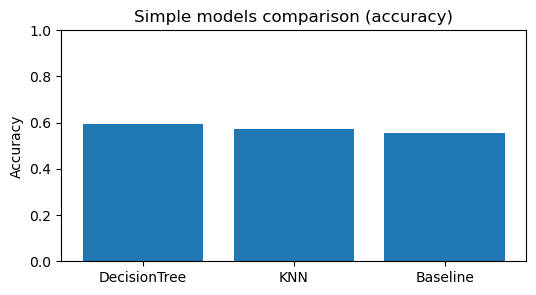

In [19]:
# Simple models comparison: Decision Tree, KNN, Baseline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# Use existing train/test split
Xtr = X_train.fillna(0)
Xte = X_test.fillna(0)

models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Baseline': DummyClassifier(strategy='most_frequent'),
}

results = []
for name, m in models.items():
    try:
        m.fit(Xtr, y_train)
        y_pred_m = m.predict(Xte)
        acc = accuracy_score(y_test, y_pred_m)
        try:
            y_proba = m.predict_proba(Xte)[:, 1]
            auc = roc_auc_score(y_test, y_proba)
        except Exception:
            auc = np.nan
        print(f"--- {name} ---\nAccuracy: {acc:.3%}, AUC: {auc if not np.isnan(auc) else 'N/A'}")
        print(classification_report(y_test, y_pred_m))
        results.append({'model': name, 'accuracy': acc, 'auc': auc})
    except Exception as e:
        print(f"{name} failed: {e}")

results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
print('\nSummary:')
results_df

# Plot accuracies
plt.figure(figsize=(6,3))
plt.bar(results_df['model'], results_df['accuracy'], color='tab:blue')
plt.title('Simple models comparison (accuracy)')
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.show()

## Time-Based Split And Training

This section creates a chronological train/test split, then trains the main XGBoost classifier.

In [20]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import accuracy_score
import xgboost as xgb
import pandas as pd

# Hyperparameter tuning with time-aware CV
param_distributions = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_lambda': [1, 2, 5, 10],

}

base_tune_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

tscv_tune = TimeSeriesSplit(n_splits=4)
random_search = RandomizedSearchCV(
    estimator=base_tune_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='accuracy',
    cv=tscv_tune,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)


best_model = random_search.best_estimator_
best_cv_score = random_search.best_score_
best_params = random_search.best_params_

# Compare tuned model performance on holdout set

y_pred_tuned = best_model.predict(X_test)
tuned_test_accuracy = accuracy_score(y_test, y_pred_tuned)


print('Best CV Accuracy:', round(best_cv_score, 4))
print('Best Hyperparameters:')
print(best_params)
print('Tuned Test Accuracy:', round(tuned_test_accuracy, 4))


model = best_model

cv_results_df = pd.DataFrame(random_search.cv_results_).sort_values('rank_test_score')
display(cv_results_df[['rank_test_score', 'mean_test_score', 'std_test_score', 'params']].head(10))

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best CV Accuracy: 0.5997
Best Hyperparameters:
{'subsample': 0.8, 'reg_lambda': 10, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.9}
Tuned Test Accuracy: 0.6322


,rank_test_score,mean_test_score,std_test_score,params
17,1,0.599734,0.018437,"{'subsample': 0.8, 'reg_lambda': 10, 'n_estima..."
11,2,0.598594,0.020350,"{'subsample': 0.9, 'reg_lambda': 1, 'n_estimat..."
1,3,0.597454,0.023051,"{'subsample': 0.7, 'reg_lambda': 10, 'n_estima..."
2,4,0.597264,0.013368,"{'subsample': 0.7, 'reg_lambda': 2, 'n_estimat..."
13,5,0.595365,0.019525,"{'subsample': 0.7, 'reg_lambda': 2, 'n_estimat..."
15,6,0.592515,0.018240,"{'subsample': 1.0, 'reg_lambda': 2, 'n_estimat..."
14,7,0.592325,0.020315,"{'subsample': 0.8, 'reg_lambda': 1, 'n_estimat..."
9,8,0.590805,0.015743,"{'subsample': 1.0, 'reg_lambda': 2, 'n_estimat..."
7,9,0.589286,0.013598,"{'subsample': 0.9, 'reg_lambda': 5, 'n_estimat..."
18,10,0.589096,0.019450,"{'subsample': 0.8, 'reg_lambda': 1, 'n_estimat..."


## Evaluation And Model Diagnostics

Includes:
- baseline accuracy and classification report
- model comparisons and time-series CV
- feature importance and drift checks

## XGBoost Prediction

In [21]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy on 2025-2026 fights: {accuracy:.2%}")

Baseline Accuracy on 2025-2026 fights: 63.22%


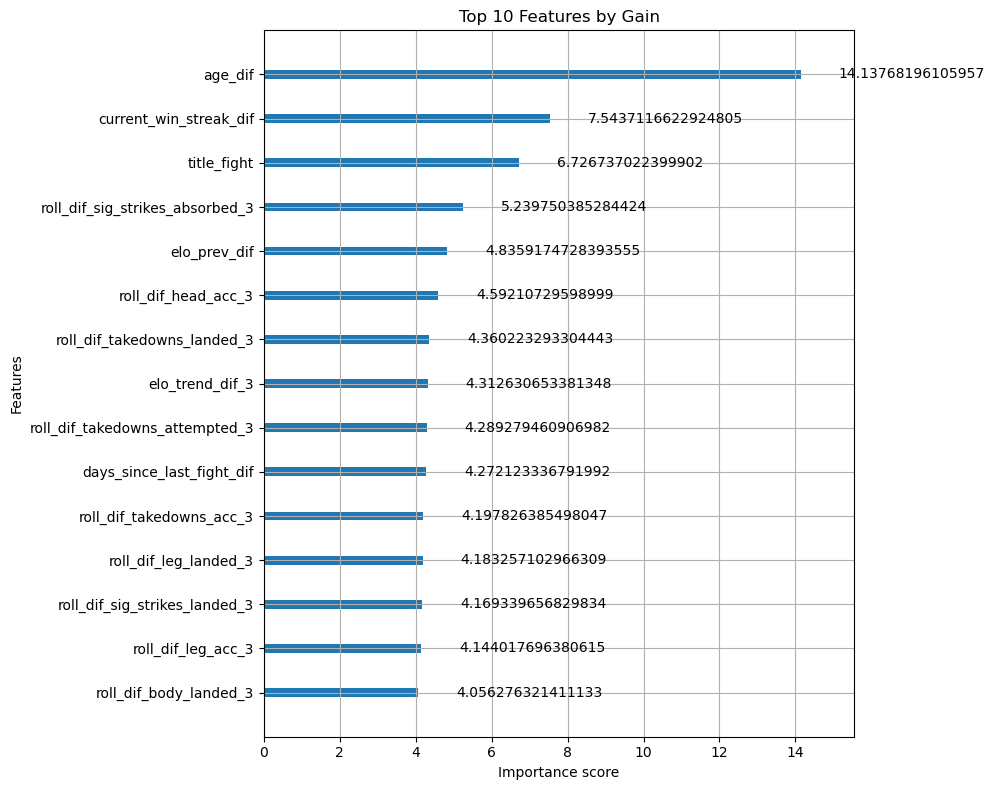

In [22]:


# 1. Increase the figure size (width, height) to prevent label crowding
plt.figure(figsize=(10, 8))

# 2. Use 'gain' instead of 'weight' for a more meaningful metric 
# (Gain measures the improvement in accuracy brought by a feature)
# 3. Limit to top 10-15 features for maximum readability
import xgboost as xgb
xgb.plot_importance(model, max_num_features=15, importance_type='gain', ax=plt.gca())

# 4. Clean up the layout
plt.title("Top 10 Features by Gain")
plt.tight_layout() 
plt.show()

Top 15 features from the full training model:


,feature,gain
0,age_dif,14.137682
1,current_win_streak_dif,7.543712
2,title_fight,6.726737
3,roll_dif_sig_strikes_absorbed_3,5.239750
4,elo_prev_dif,4.835917
5,roll_dif_head_acc_3,4.592107
6,roll_dif_takedowns_landed_3,4.360223
7,elo_trend_dif_3,4.312631
8,roll_dif_takedowns_attempted_3,4.289279
9,days_since_last_fight_dif,4.272123


Top 15 features from the 2025-2026-only model:


,feature,gain
0,age_dif,4.315485
1,current_win_streak_dif,3.665041
2,roll_dif_control_time_3,3.235225
3,roll_dif_body_landed_3,2.693485
4,roll_dif_takedowns_landed_3,2.571315
5,roll_dif_takedowns_acc_3,2.490060
6,roll_dif_sig_strikes_absorbed_3,2.462707
7,prospect_dif,2.461781
8,roll_dif_head_acc_3,2.404366
9,roll_dif_body_attempted_3,2.338349


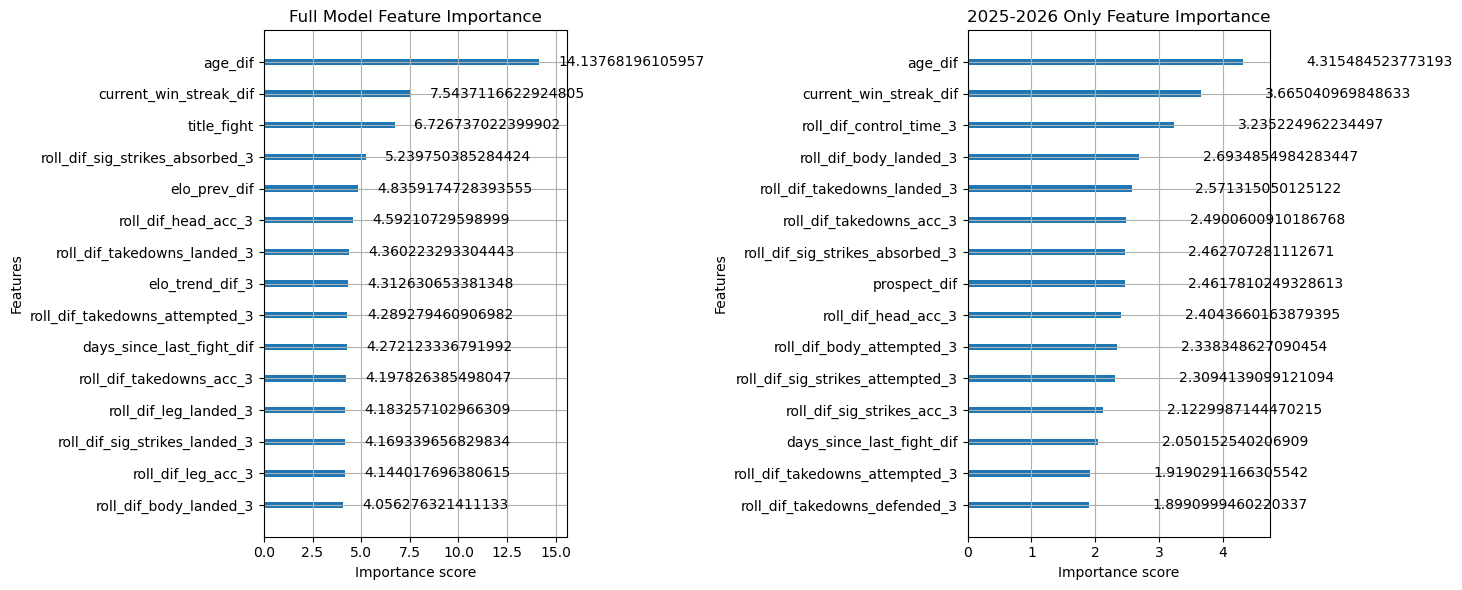

In [23]:

# Fit a separate model on the 2025-2026 slice to check whether feature priorities changed
X_2526 = test_df[X_cols].fillna(0)
y_2526 = test_df['target']

model_2526 = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model_2526.fit(X_2526, y_2526)

def _importance_frame(fitted_model, feature_names):
    gain_map = fitted_model.get_booster().get_score(importance_type='gain')
    frame = pd.DataFrame({'feature': feature_names})
    frame['gain'] = frame['feature'].map(gain_map).fillna(0)
    return frame.sort_values('gain', ascending=False).reset_index(drop=True)

full_importance = _importance_frame(model, X_cols)
subset_importance = _importance_frame(model_2526, X_cols)


print('Top 15 features from the full training model:')
display(full_importance.head(15))

print('Top 15 features from the 2025-2026-only model:')
display(subset_importance.head(15))


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
xgb.plot_importance(model, max_num_features=15, importance_type='gain', ax=axes[0])
axes[0].set_title('Full Model Feature Importance')
xgb.plot_importance(model_2526, max_num_features=15, importance_type='gain', ax=axes[1])
axes[1].set_title('2025-2026 Only Feature Importance')
plt.tight_layout()
plt.show()

Evaluation Metrics:


,Value
Accuracy,0.632201
Precision,0.619137
Recall,0.877660
F1 Score,0.726073
ROC AUC,0.678510



Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.33      0.44       301
           1       0.62      0.88      0.73       376

    accuracy                           0.63       677
   macro avg       0.65      0.60      0.58       677
weighted avg       0.65      0.63      0.60       677



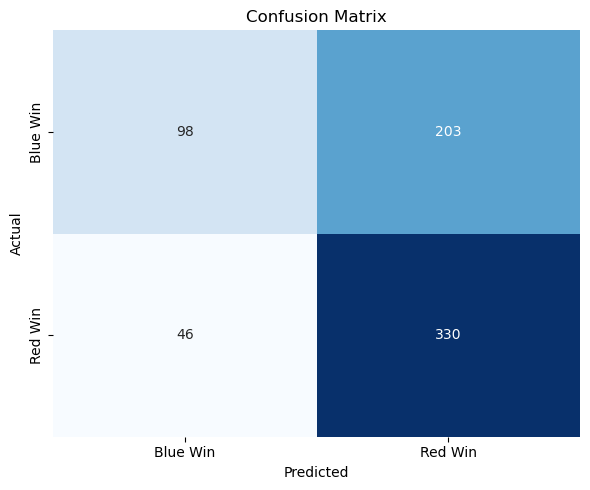

In [24]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns


# Recompute predictions for this evaluation block
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, zero_division=0),
    'ROC AUC': roc_auc_score(y_test, y_proba),
}

metrics_df = pd.DataFrame(metrics, index=['Value']).T
print('Evaluation Metrics:')
display(metrics_df)

print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Blue Win', 'Red Win'],
            yticklabels=['Blue Win', 'Red Win'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Train vs Test Accuracy:


,Split,Accuracy
0,Train,0.674316
1,Test,0.632201


Accuracy gap (Train - Test): 4.21%


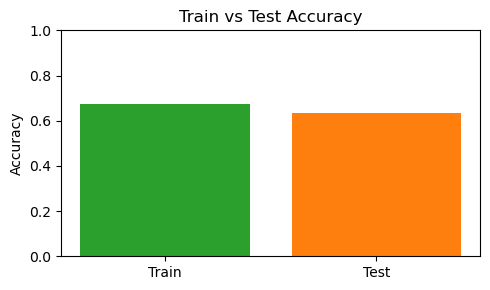

In [25]:
from sklearn.metrics import accuracy_score


# Train vs test accuracy to inspect overfitting / underfitting
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
accuracy_gap = train_accuracy - test_accuracy

accuracy_df = pd.DataFrame(
    {
        'Split': ['Train', 'Test'],
        'Accuracy': [train_accuracy, test_accuracy],
    }
)

print('Train vs Test Accuracy:')
display(accuracy_df)
print(f'Accuracy gap (Train - Test): {accuracy_gap:.2%}')


plt.figure(figsize=(5, 3))
plt.bar(accuracy_df['Split'], accuracy_df['Accuracy'], color=['tab:green', 'tab:orange'])
plt.ylim(0, 1)
plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

## FINAL PREDICTIONS BELOW

In [27]:
# The "Production" Model
final_model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)

# X and y are your ENTIRE dataset (no split)
X_final = df[X_cols].fillna(0)
y_final = df['target']

final_model.fit(X_final, y_final)

# Now use THIS model to predict the upcoming weekend's fights
# probability = final_model.predict_proba(upcoming_fight_row)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
# 1. Get the most recent row for each fighter
red_fighter = "Khamzat Chimaev" 
blue_fighter = "Sean Strickland"

fighter_r_stats = df[df['r_name'] == red_fighter].sort_values('date').iloc[-1]
fighter_b_stats = df[df['b_name'] == blue_fighter].sort_values('date').iloc[-1]

# 2. Extract the 'hist' and 'rolling' features
# Note: You use Fighter A's stats for the "Red" side and Fighter B's for "Blue"

In [29]:
def create_prediction_row(red_name, blue_name, fight_date, df, feature_cols):


    # define same suffix groups used when building training features
    rolling_suffixes = [
        'sig_strikes_landed', 'sig_strikes_attempted',
        'ground_strikes_landed', 'ground_strikes_attempted',
        'head_landed', 'head_attempted',
        'body_landed', 'body_attempted',
        'leg_landed', 'leg_attempted',
        'takedowns_landed', 'takedowns_attempted',
        'control_time', 'takedowns_defended',
        'sig_strikes_absorbed',
    ]
    accuracy_map = {
        'sig_strikes': ('sig_strikes_landed','sig_strikes_attempted'),
        'ground_strikes': ('ground_strikes_landed','ground_strikes_attempted'),
        'head': ('head_landed','head_attempted'),
        'body': ('body_landed','body_attempted'),
        'leg': ('leg_landed','leg_attempted'),
        'takedowns': ('takedowns_landed','takedowns_attempted'),
    }

    benchmark_pairs = {
        'sig_landed_3': ('r_roll_sig_strikes_landed_3', 'b_roll_sig_strikes_landed_3'),
        'td_landed_3': ('r_roll_takedowns_landed_3', 'b_roll_takedowns_landed_3'),
        'sig_acc_3': ('r_roll_sig_strikes_acc_3', 'b_roll_sig_strikes_acc_3'),
        'td_acc_3': ('r_roll_takedowns_acc_3', 'b_roll_takedowns_acc_3'),
    }

    thresholds = {}
    for key, (r_col, b_col) in benchmark_pairs.items():
        pooled = pd.concat([
            df.get(r_col, pd.Series(dtype=float)).fillna(0),
            df.get(b_col, pd.Series(dtype=float)).fillna(0)
        ], ignore_index=True)
        thresholds[key] = pooled.mean() if len(pooled) else 0

    def _prospect_flag(stats, age_cap=28, min_fights=3):
        age = stats.get('age')
        fights = stats.get('total_fights') or 0
        wins = stats.get('total_wins') or 0
        win_rate = (wins / fights) if fights else 0

        perf_score = 0
        perf_score += int((stats.get('sig_strikes_landed_3') or 0) > thresholds['sig_landed_3'])
        perf_score += int((stats.get('takedowns_landed_3') or 0) > thresholds['td_landed_3'])
        perf_score += int((stats.get('sig_strikes_acc_3') or 0) > thresholds['sig_acc_3'])
        perf_score += int((stats.get('takedowns_acc_3') or 0) > thresholds['td_acc_3'])

        young = pd.notna(age) and age < age_cap
        strong_record = fights >= min_fights and win_rate >= 0.6
        above_avg_stats = perf_score >= 2
        return int(young and strong_record and above_avg_stats)

    def _latest_stats(name):
        rows = df[(df['r_name'] == name) | (df['b_name'] == name)].sort_values('date')
        if rows.empty:
            return {}
        last = rows.iloc[-1]
        is_red = (last['r_name'] == name)
        stats = {}
        # basic identifiers / dob
        stats['dob'] = last['r_dob'] if is_red else last['b_dob']

        # snapshot and rolling keys
        for s in rolling_suffixes:
            stats[s] = last.get(f"{'r_hist_' if is_red else 'b_hist_'}{s}", 0) or 0
            stats[f"{s}_3"] = last.get(f"{'r_roll_' if is_red else 'b_roll_'}{s}_3", 0) or 0

        # accuracy keys (hist and rolling)
        for name_acc, _ in accuracy_map.items():
            stats[f"{name_acc}_acc"] = last.get(f"{'r_hist_' if is_red else 'b_hist_'}{name_acc}_acc", 0) or 0
            stats[f"{name_acc}_acc_3"] = last.get(f"{'r_roll_' if is_red else 'b_roll_'}{name_acc}_acc_3", 0) or 0

        # elo and trends
        stats['prev_elo'] = last.get('r_prev_elo') if is_red else last.get('b_prev_elo')
        stats['elo_trend_3'] = last.get('r_elo_trend_3') if is_red else last.get('b_elo_trend_3')

        # snapshots used in extra_stats/prospect logic
        stats['current_win_streak'] = last.get('r_hist_current_win_streak') if is_red else last.get('b_hist_current_win_streak')
        stats['days_since_last_fight'] = last.get('r_hist_days_since_last_fight') if is_red else last.get('b_hist_days_since_last_fight')
        stats['age'] = last.get('r_hist_age') if is_red else last.get('b_hist_age')
        stats['total_fights'] = last.get('r_hist_total_fights') if is_red else last.get('b_hist_total_fights')
        stats['total_wins'] = last.get('r_hist_total_wins') if is_red else last.get('b_hist_total_wins')
        return stats

    r_stats = _latest_stats(red_name)
    b_stats = _latest_stats(blue_name)

    r_prospect = _prospect_flag(r_stats)
    b_prospect = _prospect_flag(b_stats)

    # build pred row keyed by feature_cols order
    pred = {}
    for col in feature_cols:
        if col == 'age_dif':
            # compute ages at fight_date using dob from latest snapshot
            try:
                r_dob = pd.to_datetime(r_stats.get('dob'))
                b_dob = pd.to_datetime(b_stats.get('dob'))
                r_age = (pd.to_datetime(fight_date) - r_dob).days / 365.25 if pd.notna(r_dob) else 0
                b_age = (pd.to_datetime(fight_date) - b_dob).days / 365.25 if pd.notna(b_dob) else 0
                pred[col] = r_age - b_age
            except Exception:
                pred[col] = 0
        elif col == 'elo_prev_dif':
            pred[col] = (r_stats.get('prev_elo') or 0) - (b_stats.get('prev_elo') or 0)
        elif col == 'prospect_dif':
            pred[col] = r_prospect - b_prospect
        elif col == 'r_is_prospect':
            pred[col] = r_prospect
        elif col == 'b_is_prospect':
            pred[col] = b_prospect
        elif col.startswith('hist_dif_'):
            s = col[len('hist_dif_'):]
            pred[col] = (r_stats.get(s) or 0) - (b_stats.get(s) or 0)
        elif col.startswith('roll_dif_'):
            s = col[len('roll_dif_'):]
            pred[col] = (r_stats.get(s) or 0) - (b_stats.get(s) or 0)
        elif col in ('title_fight',):
            pred[col] = 0
        elif col in ('r_hist_current_win_streak','b_hist_current_win_streak'):
            # side specific snapshot values
            if col.startswith('r_'):
                pred[col] = r_stats.get('current_win_streak') or 0
            else:
                pred[col] = b_stats.get('current_win_streak') or 0
        elif col in ('r_hist_days_since_last_fight','b_hist_days_since_last_fight'):
            if col.startswith('r_'):
                pred[col] = r_stats.get('days_since_last_fight') or 0
            else:
                pred[col] = b_stats.get('days_since_last_fight') or 0
        else:
            # fallback: try to resolve direct keys present in our stats dicts (e.g., sig_strikes_landed_3 or sig_strikes_landed)
            if col in r_stats:
                pred[col] = r_stats.get(col) or 0
            elif col in b_stats:
                pred[col] = b_stats.get(col) or 0
            else:
                pred[col] = 0
    # ensure ordering and types
    pred_df = pd.DataFrame([pred], columns=feature_cols)
    return pred_df

# Demo: create an upcoming fight row and predict if a trained model exists
try:
    upcoming = create_prediction_row(red_fighter, blue_fighter, pd.Timestamp.today(), df, X_cols)
    X_up = upcoming[X_cols].fillna(0)
    if 'final_model' in globals():
        prob = final_model.predict_proba(X_up)[:,1][0]
        print(f"Predicted probability that Red ({red_fighter}) wins vs Blue ({blue_fighter}): {prob:.2%}")
    else:
        print('final_model not found in globals; returning constructed feature row')
        display(upcoming.head())
except Exception as e:
    print('Prediction demo failed:', e)

Predicted probability that Red (Khamzat Chimaev) wins vs Blue (Sean Strickland): 87.02%


Top 15 features from the full training model:


,feature,gain
0,age_dif,14.137682
1,current_win_streak_dif,7.543712
2,title_fight,6.726737
3,roll_dif_sig_strikes_absorbed_3,5.239750
4,elo_prev_dif,4.835917
5,roll_dif_head_acc_3,4.592107
6,roll_dif_takedowns_landed_3,4.360223
7,elo_trend_dif_3,4.312631
8,roll_dif_takedowns_attempted_3,4.289279
9,days_since_last_fight_dif,4.272123


Top 15 features from the 2025-2026-only model:


,feature,gain
0,age_dif,4.315485
1,current_win_streak_dif,3.665041
2,roll_dif_control_time_3,3.235225
3,roll_dif_body_landed_3,2.693485
4,roll_dif_takedowns_landed_3,2.571315
5,roll_dif_takedowns_acc_3,2.490060
6,roll_dif_sig_strikes_absorbed_3,2.462707
7,prospect_dif,2.461781
8,roll_dif_head_acc_3,2.404366
9,roll_dif_body_attempted_3,2.338349


Top feature comparison:


,feature,full_gain,subset_gain
0,age_dif,14.137682,4.315485
1,current_win_streak_dif,7.543712,3.665041
8,roll_dif_control_time_3,0.000000,3.235225
7,roll_dif_body_landed_3,4.056276,2.693485
19,roll_dif_takedowns_landed_3,4.360223,2.571315
16,roll_dif_takedowns_acc_3,4.197826,2.490060
12,roll_dif_sig_strikes_absorbed_3,5.239750,2.462707
5,prospect_dif,0.000000,2.461781
9,roll_dif_head_acc_3,4.592107,2.404366
6,roll_dif_body_attempted_3,0.000000,2.338349


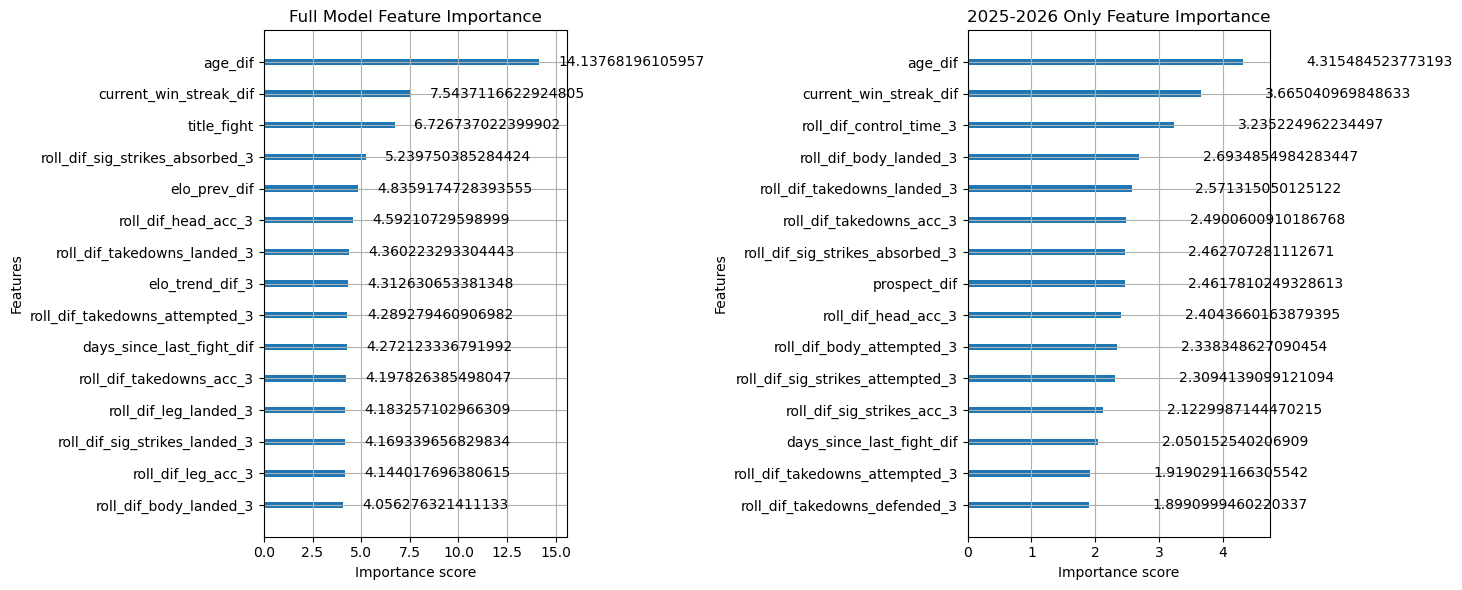

In [30]:


# Fit a separate model on the 2025-2026 slice to check whether feature priorities changed
X_2526 = test_df[X_cols].fillna(0)
y_2526 = test_df['target']

model_2526 = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model_2526.fit(X_2526, y_2526)

def _importance_frame(fitted_model, feature_names):
    gain_map = fitted_model.get_booster().get_score(importance_type='gain')
    frame = pd.DataFrame({'feature': feature_names})
    frame['gain'] = frame['feature'].map(gain_map).fillna(0)
    return frame.sort_values('gain', ascending=False).reset_index(drop=True)

full_importance = _importance_frame(model, X_cols)
subset_importance = _importance_frame(model_2526, X_cols)

comparison = full_importance[['feature', 'gain']].head(15).rename(columns={'gain': 'full_gain'}).merge(
    subset_importance[['feature', 'gain']].head(15).rename(columns={'gain': 'subset_gain'}),
    on='feature',
    how='outer'
).fillna(0).sort_values(['subset_gain', 'full_gain'], ascending=False)

print('Top 15 features from the full training model:')
display(full_importance.head(15))

print('Top 15 features from the 2025-2026-only model:')
display(subset_importance.head(15))

print('Top feature comparison:')
display(comparison.head(15))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
xgb.plot_importance(model, max_num_features=15, importance_type='gain', ax=axes[0])
axes[0].set_title('Full Model Feature Importance')
xgb.plot_importance(model_2526, max_num_features=15, importance_type='gain', ax=axes[1])
axes[1].set_title('2025-2026 Only Feature Importance')
plt.tight_layout()
plt.show()

## ELO CHART: SEE HOW YOUR FAVORITE FIGHTER'S ELO HAS CHANGED THROUGHOUT THE YEARS

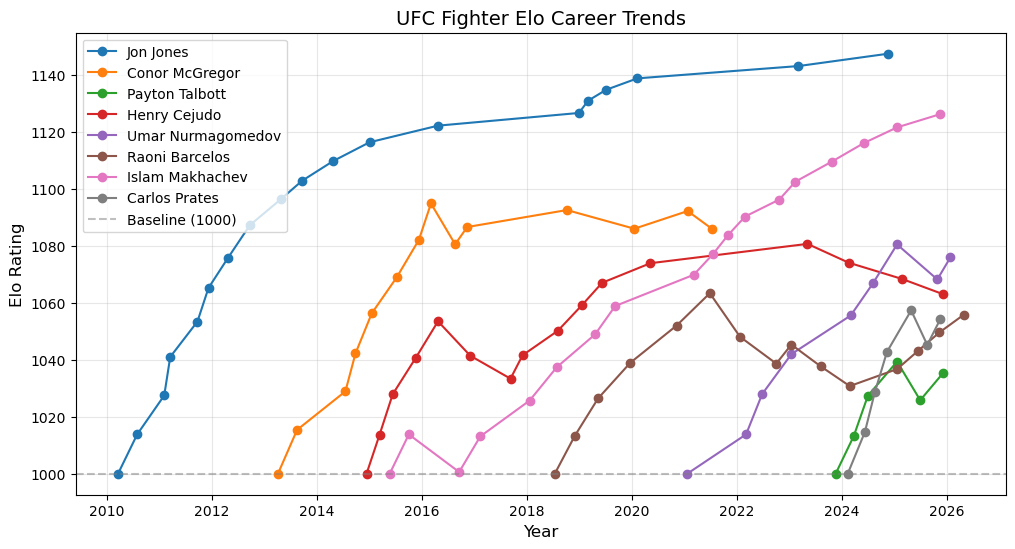

In [ ]:
def plot_fighter_elo_trends(df, fighter_names):
    plt.figure(figsize=(12, 6))
    
    for fighter in fighter_names:
        
        red_fights = df[df['r_name'] == fighter][['date', 'r_hist_elo']].rename(columns={'r_hist_elo': 'elo'})
        blue_fights = df[df['b_name'] == fighter][['date', 'b_hist_elo']].rename(columns={'b_hist_elo': 'elo'})
        
        # Combine and sort by date
        fighter_history = pd.concat([red_fights, blue_fights]).sort_values('date')
        
        # Plot the trend
        plt.plot(fighter_history['date'], fighter_history['elo'], marker='o', label=fighter)

    plt.title('UFC Fighter Elo Career Trends', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Elo Rating', fontsize=12)
    plt.axhline(y=1000, color='gray', linestyle='--', alpha=0.5, label='Baseline (1000)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # just enter your fighter in list ex. ['Jon Jones', 'Conor McGregor', 'Favorite Fighter']
plot_fighter_elo_trends(df, ['Jon Jones', 'Conor McGregor',  'Payton Talbott', 'Henry Cejudo', 'Umar Nurmagomedov', 'Raoni Barcelos', 'Islam Makhachev', 'Carlos Prates'])